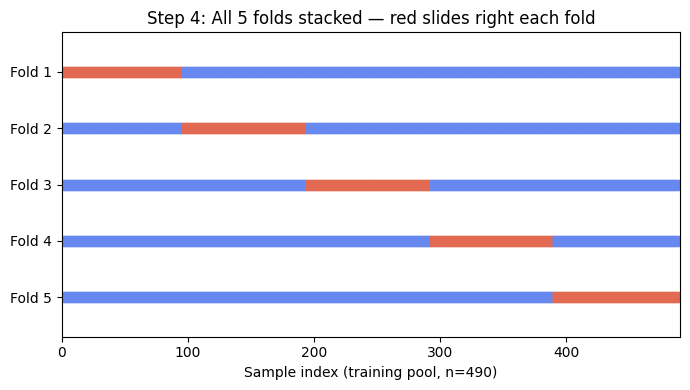

Saved: step4_five_folds.png


In [10]:
# STEP 4 — Stack 5 folds manually
# Each fold shifts the red (validation) block by one FOLD_SIZE

import matplotlib.pyplot as plt
import numpy as np

N_TRAIN   = 490
N_SPLITS  = 5
FOLD_SIZE = N_TRAIN // N_SPLITS  # = 98

fig, ax = plt.subplots(figsize=(7, 4))

for fold in range(N_SPLITS):
    # Build color array for this fold
    colors = np.zeros(N_TRAIN)           # all blue (training)
    val_start = fold * FOLD_SIZE
    val_end   = val_start + FOLD_SIZE
    colors[val_start:val_end] = 1        # red (validation) block

    ax.scatter(
        range(N_TRAIN),
        [fold + 0.5] * N_TRAIN,   # each fold on a different row
        c=colors,
        marker="_",
        lw=8,
        cmap=plt.cm.coolwarm,
        vmin=-0.2, vmax=1.2,
    )

ax.set_xlim(0, N_TRAIN)
ax.set_ylim(N_SPLITS + 0.2, -0.2)   # flip y so fold 1 is on top
ax.set_yticks(np.arange(N_SPLITS) + 0.5)
ax.set_yticklabels([f"Fold {i+1}" for i in range(N_SPLITS)])
ax.set_xlabel("Sample index (training pool, n=490)")
ax.set_title("Step 4: All 5 folds stacked — red slides right each fold")

plt.tight_layout()
plt.savefig("step4_five_folds.png", dpi=150)
plt.show()
print("Saved: step4_five_folds.png")

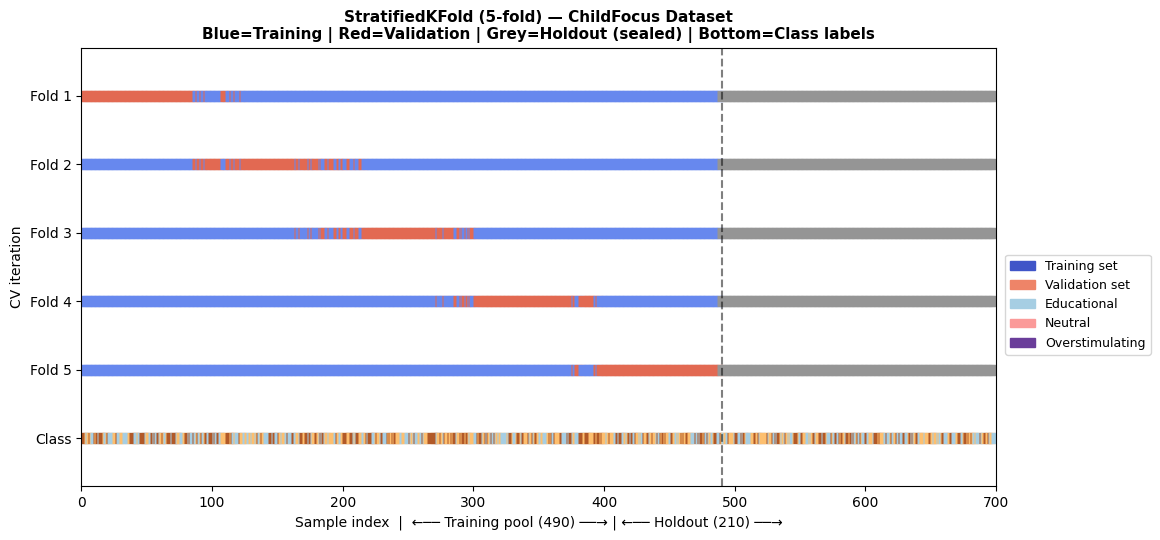

Saved: step6_final_figure.png


In [9]:
# STEP 6 — Complete research figure
# Add: class label strip at bottom + sealed holdout on the right

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from sklearn.model_selection import StratifiedKFold

N_TOTAL  = 700
N_TRAIN  = 490
N_TEST   = 210
N_SPLITS = 5

np.random.seed(42)
y_train = np.array([0]*161 + [1]*164 + [2]*165)
np.random.shuffle(y_train)
y_test = np.array([0]*69 + [1]*71 + [2]*70)
np.random.shuffle(y_test)

X_dummy = np.zeros((N_TRAIN, 1))
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=False)

cmap_cv   = plt.cm.coolwarm
cmap_data = plt.cm.Paired

fig, ax = plt.subplots(figsize=(13, 5.5))

# ── CV fold rows ───────────────────────────────────────────────────────────
for fold, (train_idx, val_idx) in enumerate(skf.split(X_dummy, y_train)):
    colors = np.full(N_TRAIN, np.nan)
    colors[val_idx]   = 1
    colors[train_idx] = 0

    # Training pool
    ax.scatter(range(N_TRAIN), [fold+0.5]*N_TRAIN,
               c=colors, marker="_", lw=8,
               cmap=cmap_cv, vmin=-0.2, vmax=1.2)

    # Holdout (grey, always the same — not part of CV)
    ax.scatter(range(N_TRAIN, N_TOTAL), [fold+0.5]*N_TEST,
               c=[0.5]*N_TEST, marker="_", lw=8,
               cmap=plt.cm.Greys, vmin=0, vmax=1)

# ── Class label strip (last row) ───────────────────────────────────────────
y_all = np.concatenate([y_train, y_test])
ax.scatter(range(N_TOTAL), [N_SPLITS+0.5]*N_TOTAL,
           c=y_all, marker="_", lw=8,
           cmap=cmap_data, vmin=0, vmax=2)

# ── Divider line ───────────────────────────────────────────────────────────
ax.axvline(N_TRAIN, color="black", lw=1.5, linestyle="--", alpha=0.5)

# ── Labels ─────────────────────────────────────────────────────────────────
yticklabels = [f"Fold {i+1}" for i in range(N_SPLITS)] + ["Class"]
ax.set(
    yticks=np.arange(N_SPLITS+1) + 0.5,
    yticklabels=yticklabels,
    xlabel="Sample index  |  ←── Training pool (490) ──→ | ←── Holdout (210) ──→",
    ylabel="CV iteration",
    xlim=[0, N_TOTAL],
    ylim=[N_SPLITS+1.2, -0.2],
)
ax.set_title("StratifiedKFold (5-fold) — ChildFocus Dataset\n"
             "Blue=Training | Red=Validation | Grey=Holdout (sealed) | Bottom=Class labels",
             fontsize=11, fontweight="bold")

legend = [
    Patch(color=cmap_cv(0.02), label="Training set"),
    Patch(color=cmap_cv(0.8),  label="Validation set"),
    
    Patch(color=cmap_data(0.0),label="Educational"),
    Patch(color=cmap_data(0.4),label="Neutral"),
    Patch(color=cmap_data(0.8),label="Overstimulating"),
]
ax.legend(handles=legend, loc=(1.01, 0.3), fontsize=9, frameon=True)

plt.tight_layout()
fig.subplots_adjust(right=0.77)
plt.savefig("step6_final_figure.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: step6_final_figure.png")

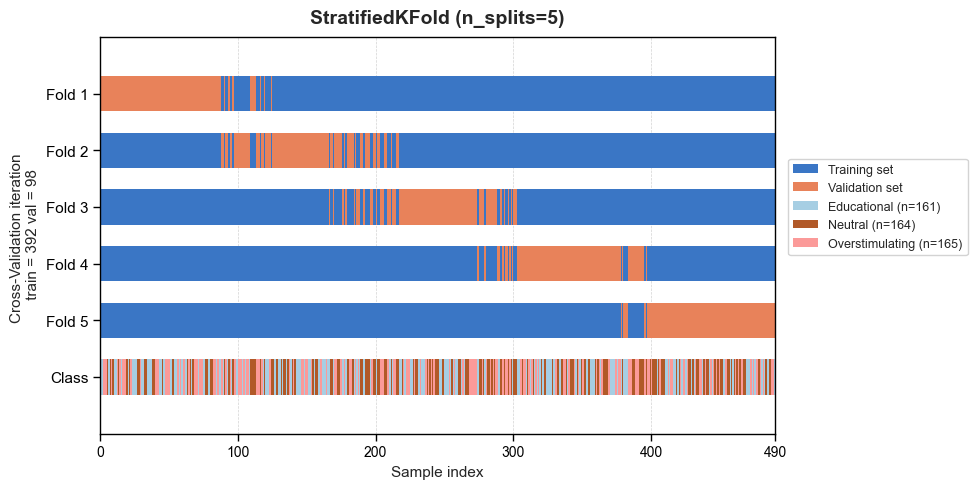

In [65]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.model_selection import StratifiedKFold

# ── Your actual class counts ───────────────────────────────────────────────
N_TRAIN  = 490
N_SPLITS = 5
np.random.seed(42)
y_train = np.array([0]*161 + [1]*164 + [2]*165)
np.random.shuffle(y_train)
X_dummy = np.zeros((N_TRAIN, 1))

# ── Colors (sklearn exact) ────────────────────────────────────────────────
TRAIN_COLOR = "#3A76C5"    # sklearn training blue
VAL_COLOR   = "#E8825A"    # sklearn validation orange-red
CLASS_COLORS = {
    0: "#A6CEE3",   # Educational   — Paired cmap light blue
    1: "#B15928",   # Neutral       — Paired cmap brown
    2: "#FB9A99",   # Overstimulating — Paired cmap light red
}

# ════════════════════════════════════════════════════════

BAR_HEIGHT  = 0.5    
ROW_PAD     = 0.8     
FIG_W       = 10      
FIG_H       = 5       
FONT_SIZE   = 11      
TITLE_SIZE  = 14      
SHOW_CLASS  = True    
# ════════════════════════════════════════════════════════

def indices_to_ranges(idx_array):
    if len(idx_array) == 0:
        return []
    idx_sorted = np.sort(idx_array)
    ranges = []
    start  = idx_sorted[0]
    prev   = idx_sorted[0]
    for v in idx_sorted[1:]:
        if v == prev + 1:
            prev = v
        else:
            ranges.append((start, prev - start + 1))
            start = v
            prev  = v
    ranges.append((start, prev - start + 1))
    return ranges

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=False)

y_positions = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_dummy, y_train)):
    y_center = fold * ROW_PAD
    y_positions.append(y_center)
    bar_bottom = y_center - BAR_HEIGHT / 2

    # Training blocks (blue)
    for start, length in indices_to_ranges(tr_idx):
        ax.broken_barh([(start, length)], (bar_bottom, BAR_HEIGHT),
                       facecolors=TRAIN_COLOR, edgecolors="none")

    # Validation blocks (red/orange)
    for start, length in indices_to_ranges(val_idx):
        ax.broken_barh([(start, length)], (bar_bottom, BAR_HEIGHT),
                       facecolors=VAL_COLOR, edgecolors="none")

# Class distribution strip
if SHOW_CLASS:
    class_y = N_SPLITS * ROW_PAD
    y_positions.append(class_y)
    bar_bottom = class_y - BAR_HEIGHT / 2
    for sample_i, cls in enumerate(y_train):
        ax.broken_barh([(sample_i, 1)], (bar_bottom, BAR_HEIGHT),
                       facecolors=CLASS_COLORS[cls], edgecolors="none")

# ── Axes formatting ───────────────────────────────────────────────────────
n_rows = N_SPLITS + (1 if SHOW_CLASS else 0)
ytick_labels = [f"Fold {i+1}" for i in range(N_SPLITS)]
if SHOW_CLASS:
    ytick_labels += ["Class"]

ax.set_yticks(y_positions)
ax.set_yticklabels(ytick_labels, fontsize=FONT_SIZE)
ax.set_xlabel("Sample index", fontsize=FONT_SIZE)
ax.set_ylabel("Cross-Validation iteration \n train = 392 val = 98", fontsize=FONT_SIZE)

# Set explicit X-ticks ending in 490
ax.set_xlim(0, N_TRAIN)
ticks = list(range(0, N_TRAIN, 100)) + [N_TRAIN]
ax.set_xticks(ticks)

# Invert so Fold 1 is on top 
ax.set_ylim(
    (N_SPLITS if SHOW_CLASS else N_SPLITS - 1) * ROW_PAD + BAR_HEIGHT + 0.3,
    -BAR_HEIGHT - 0.3
)

ax.set_title(
    "StratifiedKFold (n_splits=5)",
    fontsize=TITLE_SIZE, fontweight="bold", pad=10
)

# Add solid black outline (spines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.0)

# --- NEW: Force the physical tick marks to appear ---
ax.tick_params(axis='both', which='major', bottom=True, left=True, length=5, width=1, colors='black')

# Clean grid
ax.yaxis.grid(False)
ax.xaxis.grid(True, color="lightgray", linewidth=0.5, linestyle='--')
ax.set_axisbelow(True)

# ── Legend outside right ────────────────────────────────────
legend_patches = [
    mpatches.Patch(facecolor=TRAIN_COLOR,        label="Training set"),
    mpatches.Patch(facecolor=VAL_COLOR,          label="Validation set"),
    mpatches.Patch(facecolor=CLASS_COLORS[0],    label=f"Educational (n=161)"),
    mpatches.Patch(facecolor=CLASS_COLORS[1],    label=f"Neutral (n=164)"),
    mpatches.Patch(facecolor=CLASS_COLORS[2],    label=f"Overstimulating (n=165)"),
]
ax.legend(
    handles=legend_patches,
    loc=(1.02, 0.45),
    fontsize=9,
    frameon=True,
    framealpha=1.0,
    edgecolor="lightgray"
)

plt.tight_layout()
fig.subplots_adjust(right=0.78)
plt.savefig("cv_figure_tweaked.png", dpi=300, bbox_inches="tight")